In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/khulna.csv')
df1=df['effected-khulna']
n=len(df1)
df1=df1.reset_index(drop=True)
df1=np.abs(df1.ffill())
print(df1)

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
1091     2.0
1092     2.0
1093    20.0
1094     9.0
1095     3.0
Name: effected-khulna, Length: 1096, dtype: float64


In [2]:
#ind_rang = [(0,58),(59,119),(120,180),(181,242),(243,303),(304,364),(365,423),(424,484),(485,545),(546,607),(608,668),(669,729),(730,789),(790,850),(851,911),(912,973),(974,1034),(1035,1095)]
ind_rang=[(0,89),(90,180),(181,272),(273,364),(365,454),(455,545),(546,637),(638,729),(730,820),(821,911),(912,1003),(1004,1095)]


window = {}

for i, (start, end) in enumerate(ind_rang, start=1):
    window[i]= df1[start:end+1]

pd.set_option("display.max_rows", None)

The Max Degree: 56
The Max Degree: 17


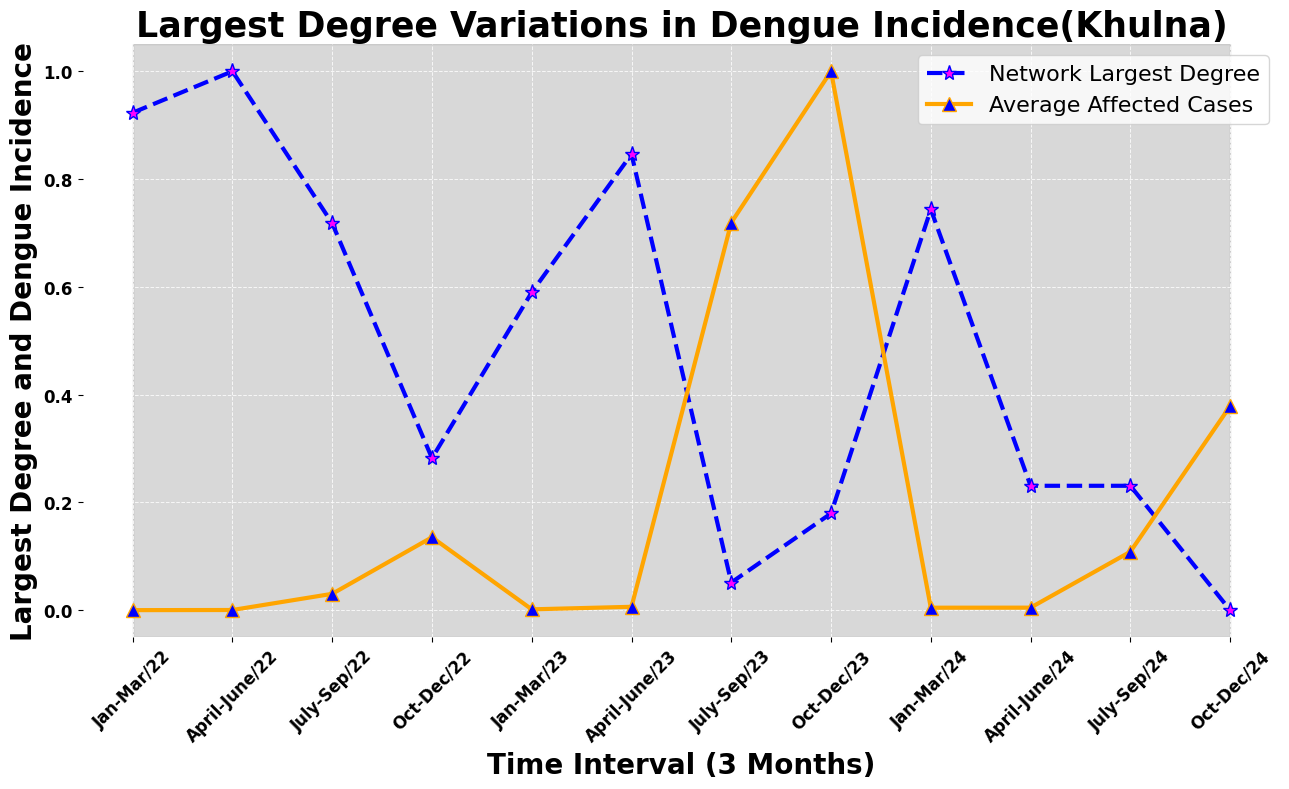

In [14]:
mxdeg1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  degree_sequence = [d for _, d in G.degree()]
  mx_degree = max(degree_sequence)
  mxdeg1.append(mx_degree)
  avg1.append(data.mean())

print("The Max Degree:", max(mxdeg1))
print("The Max Degree:", min(mxdeg1))

scaler = MinMaxScaler()
smxdeg1 = scaler.fit_transform(np.array(mxdeg1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))


fig, ax = plt.subplots(figsize=(13,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), smxdeg1,
         markerfacecolor='magenta',
         markersize=11,
        marker='*',
        linewidth=3,
        linestyle='--',
        color='blue',
        label="Network Largest Degree")

ax.plot(range(len(window)), savg1,
        markerfacecolor='blue',
        markersize=10,
        marker='^',
        linewidth=3,
        linestyle='-',
        color='orange',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('Largest Degree and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('Largest Degree Variations in Dengue Incidence(Khulna)',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper right')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlim(-0.5, len(window)-0.5)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

The maximum value of GRC is: 0.390246913580247
minimum value of GRC is: 0.19054864549370043


<Figure size 1000x600 with 0 Axes>

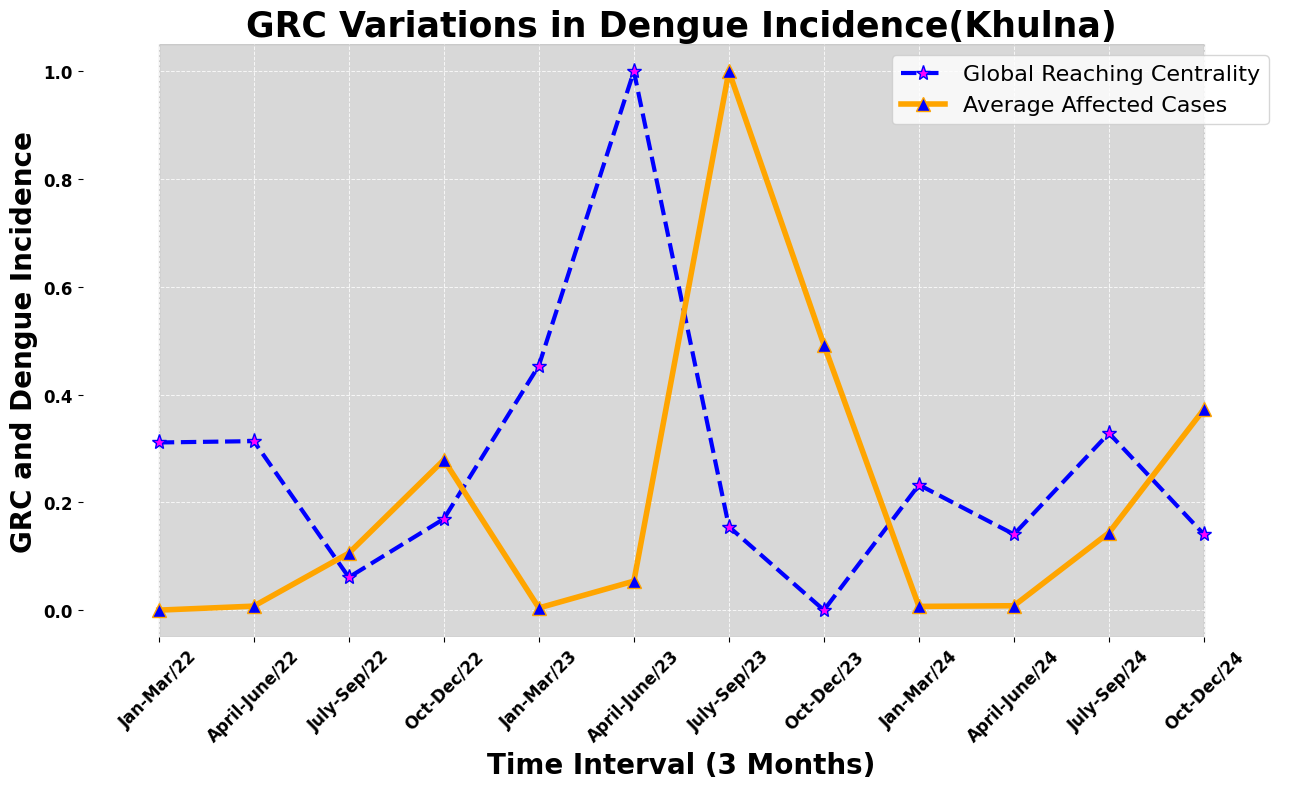

In [26]:
def reaching_centrality(data):
  vis_graph = nx.visibility_graph(data)
  if vis_graph.number_of_nodes() > 0:
    avg_gr_centrality = nx.global_reaching_centrality(vis_graph)
    return avg_gr_centrality
  else:
    return 0

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  avc1.append(reaching_centrality(data))
  average_value1.append(avg(data))


x= max(average_value1)
y=max(avc1)
#print("The GRC is:",np.mean(avc1))
print("The maximum value of GRC is:",max(avc1))
print("minimum value of GRC is:", min(avc1))
scaler = MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))
plt.figure(figsize=(10,6))
# Plotting from index 0
fig, ax = plt.subplots(figsize=(13,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), scaled_path1,
         markerfacecolor='magenta',
         markersize=11,
        marker='*',
        linewidth=3,
        linestyle='--',
        color='blue',
        label="Global Reaching Centrality")

ax.plot(range(len(window)), scaled_value1,
        markerfacecolor='blue',
        markersize=10,
        marker='^',
        linewidth=4,
        linestyle='-',
        color='orange',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('GRC and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('GRC Variations in Dengue Incidence(Khulna)',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper right')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
#plt.xlim(0, len(window)-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/Dhaka.csv')
df1=df['effected']
n=len(df1)
df1=df1.reset_index(drop=True)
df1=np.abs(df1.ffill())
#print(df1)

In [19]:
#ind_rang = [(0,58),(59,119),(120,180),(181,242),(243,303),(304,364),(365,423),(424,484),(485,545),(546,607),(608,668),(669,729),(730,789),(790,850),(851,911),(912,973),(974,1034),(1035,1095)]
ind_rang=[(0,89),(90,180),(181,272),(273,364),(365,454),(455,545),(546,637),(638,729),(730,820),(821,911),(912,1003),(1004,1095)]


window = {}

for i, (start, end) in enumerate(ind_rang, start=1):
    window[i]= df1[start:end+1]

The maximum value of GRC is: 0.390246913580247
minimum value of GRC is: 0.19054864549370043


<Figure size 1000x600 with 0 Axes>

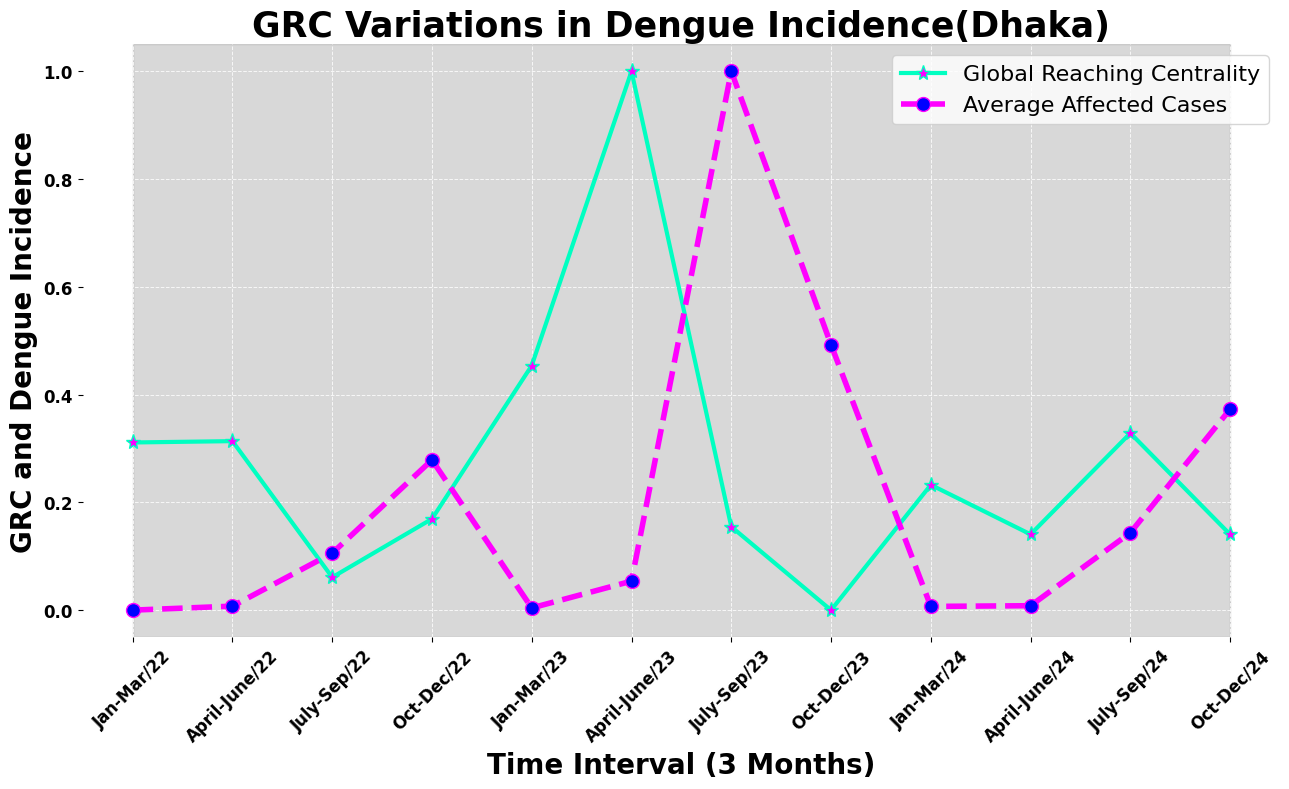

In [23]:
def reaching_centrality(data):
  vis_graph = nx.visibility_graph(data)
  if vis_graph.number_of_nodes() > 0:
    avg_gr_centrality = nx.global_reaching_centrality(vis_graph)
    return avg_gr_centrality
  else:
    return 0

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  avc1.append(reaching_centrality(data))
  average_value1.append(avg(data))


x= max(average_value1)
y=max(avc1)
#print("The GRC is:",np.mean(avc1))
print("The maximum value of GRC is:",max(avc1))
print("minimum value of GRC is:", min(avc1))
scaler = MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))
plt.figure(figsize=(10,6))
# Plotting from index 0
fig, ax = plt.subplots(figsize=(13,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), scaled_path1,
         markerfacecolor='magenta',
         markersize=11,
        marker='*',
        linewidth=3,
        linestyle='-',
        color='#00ffc1',
        label="Global Reaching Centrality")

ax.plot(range(len(window)), scaled_value1,
        markerfacecolor='blue',
        markersize=10,
        marker='o',
        linewidth=4,
        linestyle='--',
        color='magenta',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('GRC and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('GRC Variations in Dengue Incidence(Dhaka)',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper right')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
#plt.xlim(0, len(window)-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlim(-0.5, len(window)-0.5)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

The Max Degree: 73
The Min Degree: 22


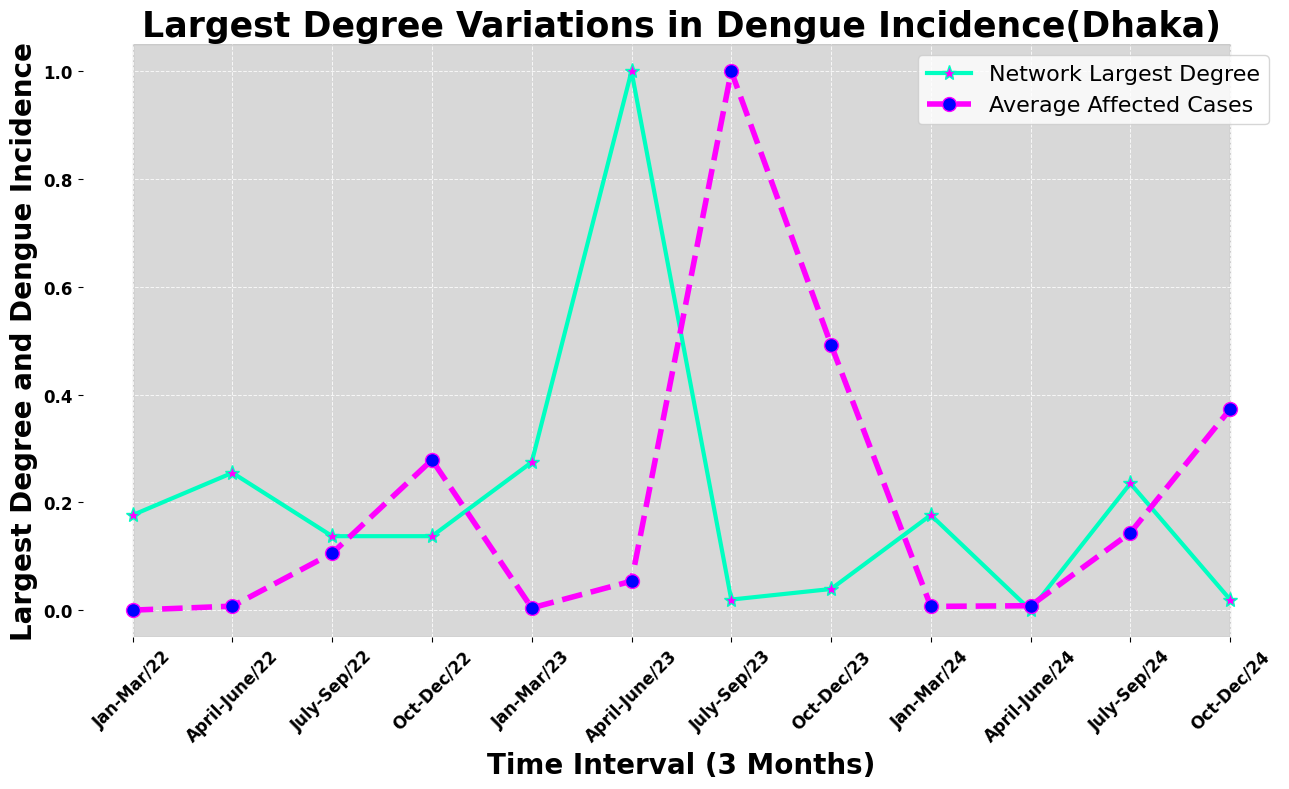

In [24]:
mxdeg1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  degree_sequence = [d for _, d in G.degree()]
  mx_degree = max(degree_sequence)
  mxdeg1.append(mx_degree)
  avg1.append(data.mean())

print("The Max Degree:", max(mxdeg1))
print("The Min Degree:", min(mxdeg1))
scaler = MinMaxScaler()
smxdeg1 = scaler.fit_transform(np.array(mxdeg1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))
fig, ax = plt.subplots(figsize=(13,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), smxdeg1,
         markerfacecolor='magenta',
         markersize=11,
        marker='*',
        linewidth=3,
        linestyle='-',
        color='#00ffc1',
        label="Network Largest Degree")

ax.plot(range(len(window)), savg1,
        markerfacecolor='blue',
        markersize=10,
        marker='o',
        linewidth=4,
        linestyle='--',
        color='magenta',
        label="Average Affected Cases")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('Largest Degree and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('Largest Degree Variations in Dengue Incidence(Dhaka)',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper right')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
#plt.xlim(0, len(window)-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlim(-0.5, len(window)-0.5)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

The maximum value of GRC is: 0.390246913580247
minimum value of GRC is: 0.19054864549370043


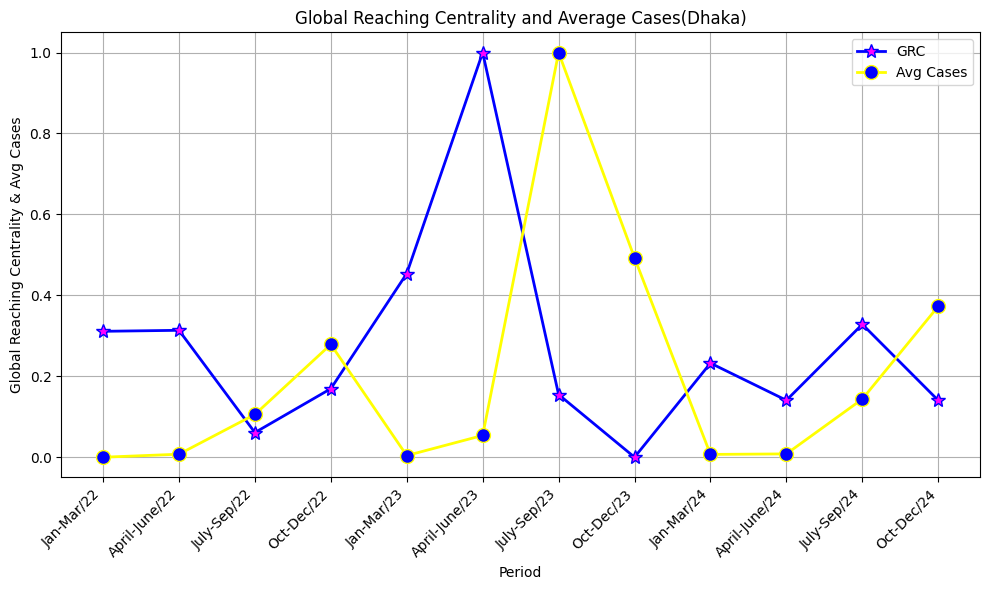

In [ ]:
def reaching_centrality(data):
  vis_graph = nx.visibility_graph(data)
  if vis_graph.number_of_nodes() > 0:
    avg_gr_centrality = nx.global_reaching_centrality(vis_graph)
    return avg_gr_centrality
  else:
    return 0

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  avc1.append(reaching_centrality(data))
  average_value1.append(avg(data))


x= max(average_value1)
y=max(avc1)
#print("The GRC is:",np.mean(avc1))
#print("The GRC is:",np.mean(avc1))
print("The maximum value of GRC is:",max(avc1))
print("minimum value of GRC is:", min(avc1))
scaler = MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))
plt.figure(figsize=(10,6))
# Plotting from index 0
plt.plot(range(len(window)), scaled_path1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='blue', label="GRC")
plt.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Cases")
#month_names = ['Jan-Feb/22', 'Mar-Apr/22', 'May-June/22', 'July-Aug/22', 'Sep-Oct/22', 'Nov-Dec/22', 'Jan-Feb/23', 'Mar-Apr/23', 'May-June/23', 'July-Aug/23', 'Sep-Oct/23', 'Nov-Dec/24', 'Mar-Apr/24', 'May-June/24', 'July-Aug/24', 'Sep-Oct/24', 'Nov-Dec/24']
month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xlabel('Period')
plt.ylabel('Global Reaching Centrality & Avg Cases')
plt.title('Global Reaching Centrality and Average Cases(Dhaka)')
# Setting xticks from index 0
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

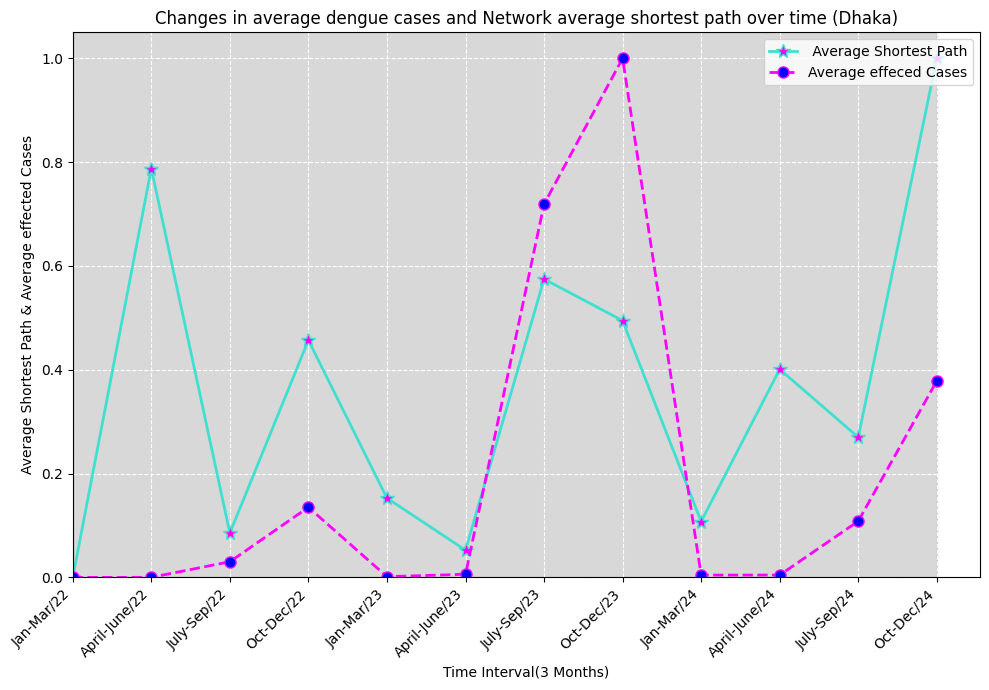

In [ ]:
#Shortest path, density, maximum degree, betwenness centrality, grc

def path(data):
   G = nx.visibility_graph(data)
   if nx.number_of_nodes(G) < 2:
        return 0
   else:
        return nx.average_shortest_path_length(G)

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []
dens=[]


for i in window:
  data=window[i]
  #print(data)
  avc1.append(path(data))
  average_value1.append(avg(data))
  #G=nx.visibility_graph(data)
  #dens.append(nx.density(G))


scaler = MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))

#sdense = scaler.fit_transform(np.array(dens).reshape(-1,1))


#plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(10,7))

ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
#ax.axvspan( color='gray', alpha=0.3)
#plt.plot(range(len(window)), sdense, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='blue', label="Density")
ax.plot(range(len(window)), scaled_path1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='turquoise', label=" Average Shortest Path")
ax.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=8, marker='o', linewidth=2, linestyle='--', color='magenta', label="Average effeced Cases")
#month_names = ['Jan-Feb/22', 'Mar-Apr/22', 'May-June/22', 'July-Aug/22', 'Sep-Oct/22', 'Nov-Dec/22', 'Jan-Feb/23', 'Mar-Apr/23', 'May-June/23', 'July-Aug/23', 'Sep-Oct/23', 'Nov-Dec/23','Jan-Feb/24', 'Mar-Apr/24', 'May-June/24', 'July-Aug/24', 'Sep-Oct/24', 'Nov-Dec/24']
month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Time Interval(3 Months)')
plt.ylabel('Average Shortest Path & Average effected Cases')
plt.title('Changes in average dengue cases and Network average shortest path over time (Dhaka)')
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.legend(loc = 'upper right')
plt.show()

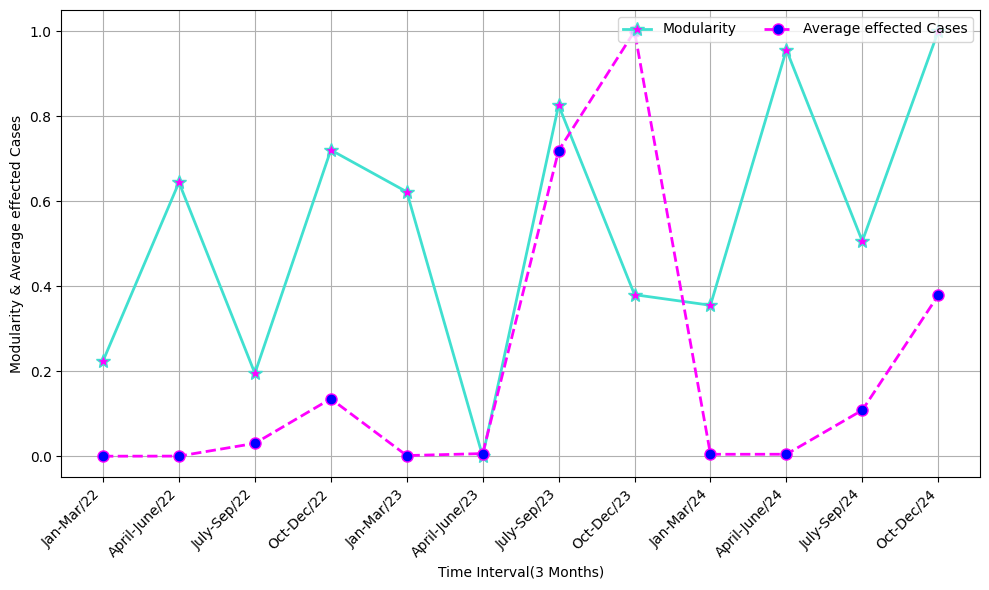

In [ ]:


mod1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  C = nx.community.greedy_modularity_communities(G)
  mod = nx.community.modularity(G, C)
  mod1.append(mod)
  avg1.append(data.mean())

smod1 = scaler.fit_transform(np.array(mod1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

plt.figure(figsize=(10,6))
plt.plot(range(len(window)), smod1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='turquoise', label="Modularity" )
plt.plot(range(len(window)), savg1, markerfacecolor='blue', markersize=8, marker='o', linewidth=2, linestyle='--', color='magenta', label="Average effected Cases" )

month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Time Interval(3 Months)')
plt.ylabel('Modularity & Average effected Cases')
#plt.title('Average Shortest Path and average cases of Chittagong(2023)')
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right', ncols=2)
plt.show()

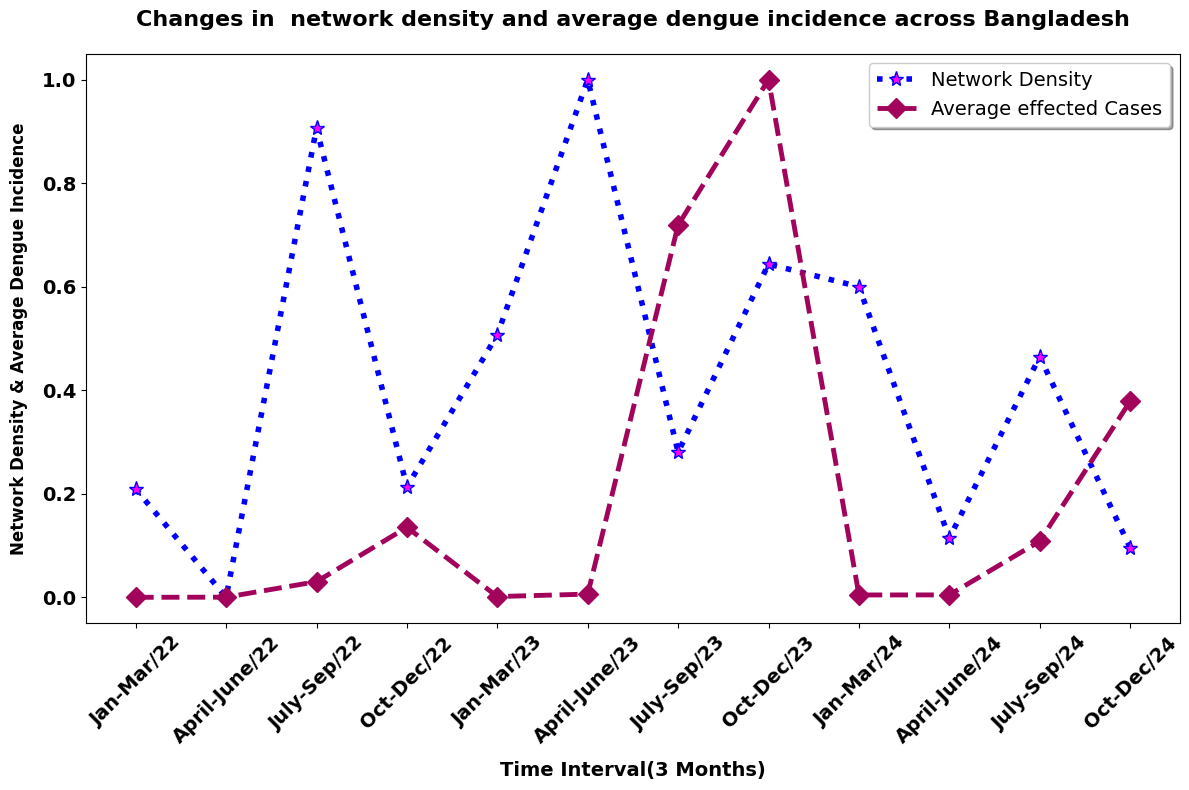

In [ ]:


dens1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  dens = nx.density(G)
  dens1.append(dens)
  avg1.append(data.mean())

sdens1 = scaler.fit_transform(np.array(dens1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

#plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(12,8), dpi=100)


ax.plot(range(len(window)), sdens1, markerfacecolor='magenta', markersize=11, marker='*', linewidth=4, linestyle=':', color='blue', label="Network Density" )
ax.plot(range(len(window)), savg1, markerfacecolor='#A1045A', markersize=10, marker='D', linewidth=3.5, linestyle='--', color='#A1045A', label="Average effected Cases" )

month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


plt.xlabel('Time Interval(3 Months)', fontsize=14, fontweight='bold', family='Arial',color='black', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Network Density & Average Dengue Incidence', fontsize=12,color='black', fontweight='bold', family='Arial', labelpad=10)
plt.title('Changes in  network density and average dengue incidence across Bangladesh', fontsize=16,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month_names)),
    labels=month_names,
    rotation=45,
    fontsize=14,
    fontweight='bold',
    family='Arial',
    color='black'

)
plt.yticks(fontsize=14, fontweight='bold', family='Arial', color='black')

plt.legend(
    fontsize=14,
    loc='upper right',
    fancybox=True,
    shadow=True,
    #prop={'weight': 'bold'}
)

plt.tight_layout()
#plt.grid(True, color='white', linestyle='--')


# Set background color for the figure
#plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='white', linestyle='--', linewidth=0.7, alpha=1)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

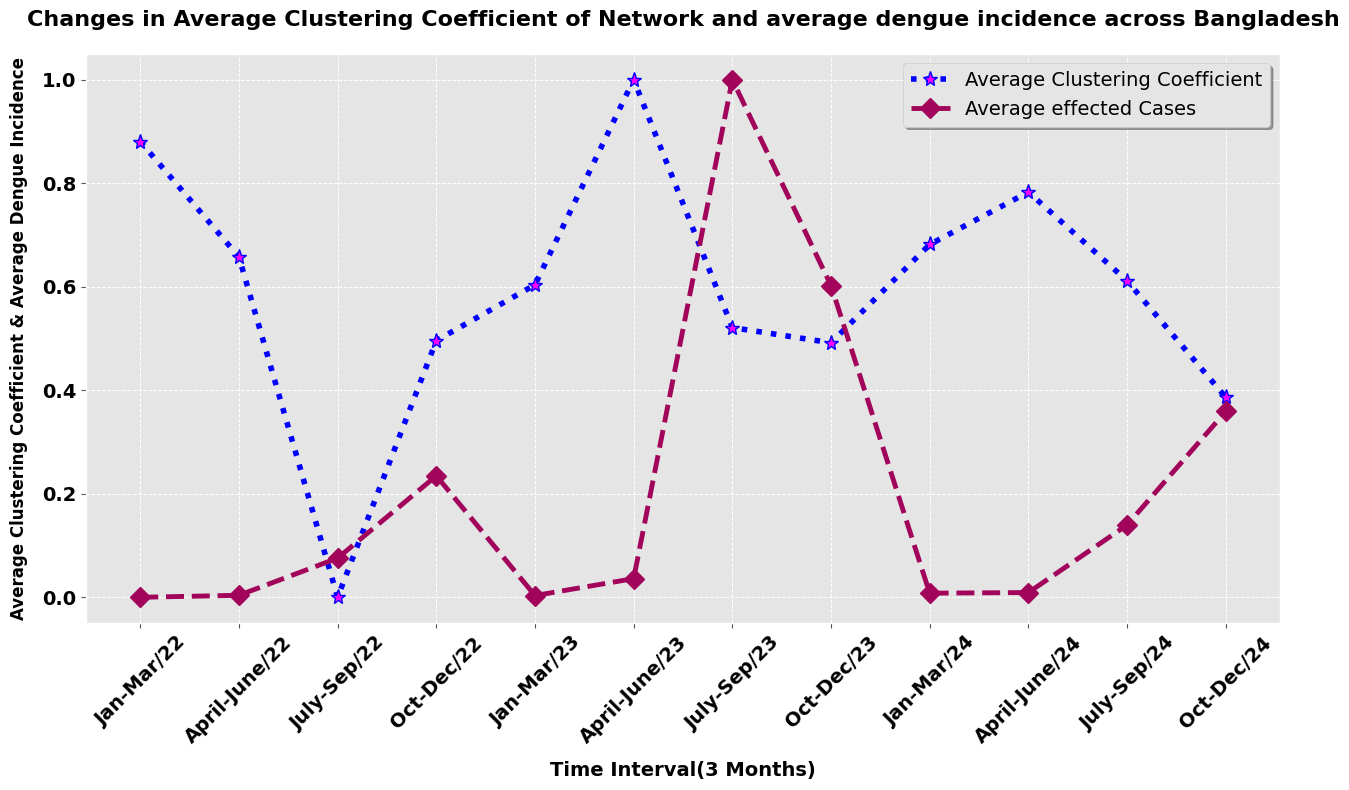

In [ ]:


grc1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  #grc = nx.global_reaching_centrality(G)
  grc = nx. average_clustering(G)
  #grc = nx.average_shortest_path_length(G)
  grc1.append(grc)
  avg1.append(data.mean())

sgrc1 = scaler.fit_transform(np.array(grc1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

#plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(13,8), dpi=100)

#ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), sgrc1, markerfacecolor='magenta', markersize=11, marker='*', linewidth=4, linestyle=':', color='blue', label="Average Clustering Coefficient" )
ax.plot(range(len(window)), savg1, markerfacecolor='#A1045A', markersize=10, marker='D', linewidth=3.5, linestyle='--', color='#A1045A', label="Average effected Cases" )

month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


plt.xlabel('Time Interval(3 Months)', fontsize=14, fontweight='bold', family='Arial',color='black', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Clustering Coefficient & Average Dengue Incidence', fontsize=12,color='black', fontweight='bold', family='Arial', labelpad=10)
plt.title('Changes in Average Clustering Coefficient of Network and average dengue incidence across Bangladesh', fontsize=16,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month_names)),
    labels=month_names,
    rotation=45,
    fontsize=14,
    fontweight='bold',
    family='Arial',
    color='black'

)
plt.yticks(fontsize=14, fontweight='bold', family='Arial', color='black')

plt.legend(
    fontsize=14,
    loc='upper right',
    fancybox=True,
    shadow=True,
    #color='white'
    #prop={'weight': 'bold'}
)

plt.tight_layout()
#plt.grid(True, color='white', linestyle='--')


# Set background color for the figure
#plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='white', linestyle='--', linewidth=0.7, alpha=1)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()


0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
20    0.0
21    0.0
22    1.0
23    0.0
24    0.0
25    0.0
26    0.0
27    0.0
28    0.0
29    0.0
30    0.0
31    0.0
32    0.0
33    0.0
34    0.0
35    0.0
36    0.0
37    0.0
38    0.0
39    0.0
40    0.0
41    0.0
42    0.0
43    0.0
44    0.0
45    1.0
46    0.0
47    0.0
48    0.0
49    0.0
50    0.0
51    0.0
52    0.0
53    0.0
54    0.0
55    0.0
56    0.0
57    0.0
58    0.0
59    0.0
60    0.0
61    0.0
62    0.0
63    0.0
64    0.0
65    0.0
66    0.0
67    0.0
68    0.0
69    0.0
70    0.0
71    0.0
72    0.0
73    0.0
74    1.0
75    0.0
76    0.0
77    0.0
78    0.0
79    0.0
80    0.0
81    2.0
82    0.0
83    0.0
84    0.0
85    0.0
86    0.0
87    0.0
88    0.0
89    0.0
Name: effected-khulna, dtype: float64
90     0.0
91     0.0
92     0.0
93     0.0
94     0.0
95     

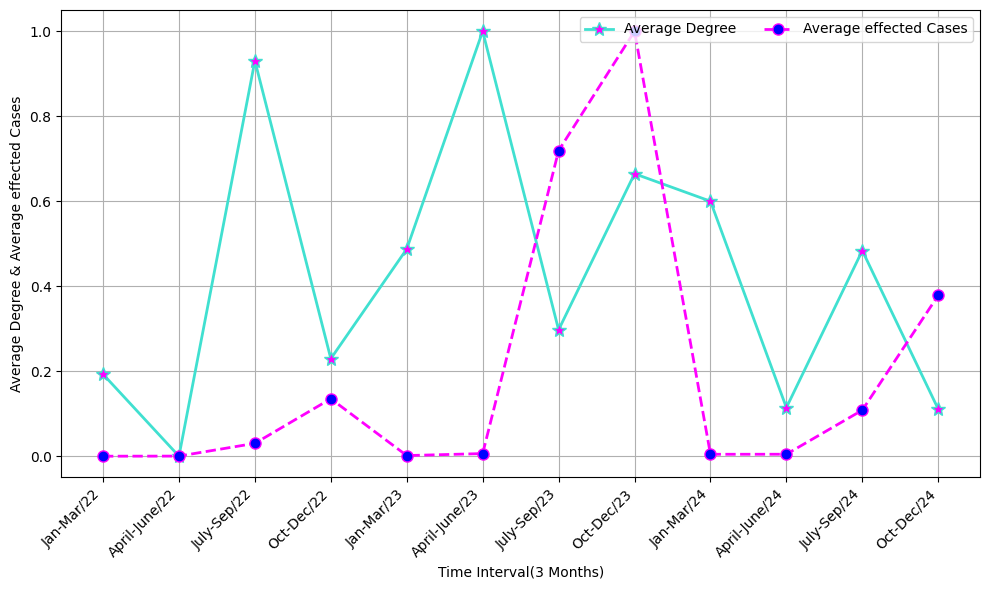

In [ ]:


avdeg1 = []
avg1 = []

for i in window:
  data = window[i]
  print(data)
  G = nx.visibility_graph(data)
  degree_sequence = [d for _, d in G.degree()]
  avg_degree = np.mean(degree_sequence)
  avdeg1.append(avg_degree)
  avg1.append(data.mean())

savdeg1 = scaler.fit_transform(np.array(avdeg1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

plt.figure(figsize=(10,6))
plt.plot(range(len(window)), savdeg1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='turquoise', label="Average Degree" )
plt.plot(range(len(window)), savg1, markerfacecolor='blue', markersize=8, marker='o', linewidth=2, linestyle='--', color='magenta', label="Average effected Cases" )

month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Time Interval(3 Months)')
plt.ylabel('Average Degree & Average effected Cases')
#plt.title('Average Shortest Path and average cases of Chittagong(2023)')
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right', ncols=2)
plt.show()



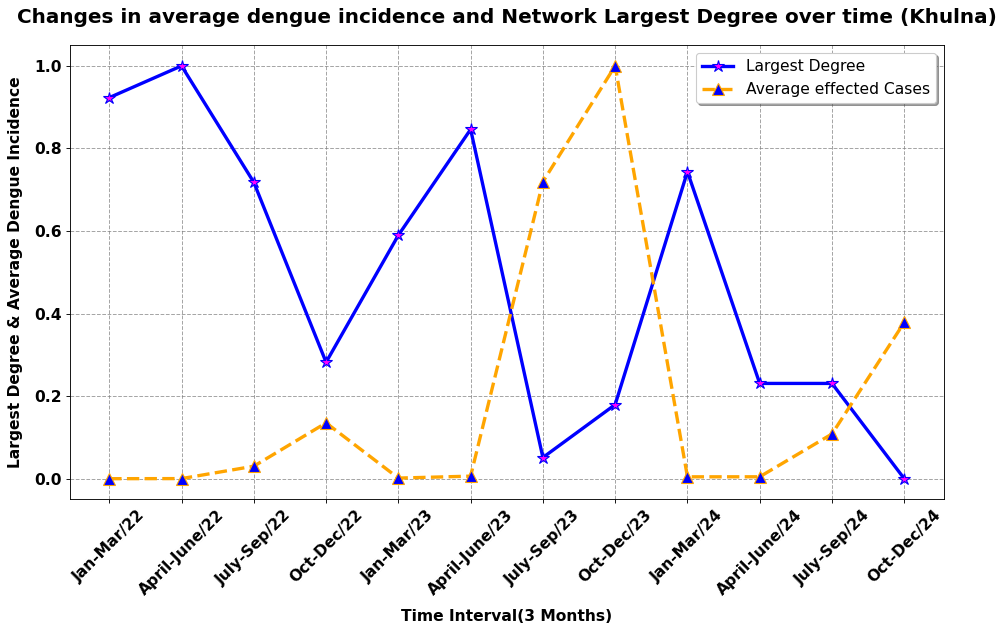

In [ ]:
mxdeg1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  degree_sequence = [d for _, d in G.degree()]
  mx_degree = max(degree_sequence)
  mxdeg1.append(mx_degree)
  avg1.append(data.mean())

smxdeg1 = scaler.fit_transform(np.array(mxdeg1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))

fig, ax = plt.subplots(figsize=(12,8), dpi=80)
#plt.style.use('ggplot')

#ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)


ax.plot(range(len(window)), smxdeg1, markerfacecolor='magenta', markersize=11, marker='*', linewidth=3, linestyle='-', color='blue', label="Largest Degree" )
ax.plot(range(len(window)), savg1, markerfacecolor='blue', markersize=10, marker='^', linewidth=3, linestyle='--', color='orange', label="Average effected Cases" )

month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Time Interval(3 Months)', fontsize=14, fontweight='bold', labelpad=10, color='black')
#plt.ylabel('Average values')
plt.ylabel('Largest Degree & Average Dengue Incidence', fontsize=14, fontweight='bold', labelpad=10, color='black')
plt.title('Changes in average dengue incidence and Network Largest Degree over time (Khulna)', fontsize=18,
    fontweight='bold',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month_names)),
    labels=month_names,
    rotation=45,
    fontsize=14,
    fontweight='bold',
    color='black'
)
plt.yticks(fontsize=14, fontweight='bold', color='black')

plt.legend(
    fontsize=14,
    loc='upper right',
    fancybox=True,
    shadow=True,
    #prop={'weight': 'bold'}
)

#plt.xlim(left=0)
#plt.ylim(bottom=0)
plt.tight_layout()
#plt.grid(True, color='white', linestyle='--')


# Set background color for the figure
#plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
#plt.grid(True, linestyle='--', alpha=0.5)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
plt.savefig('ld1.png')
plt.show()

In [ ]:
def visibility_graph(data):
    n = len(data)
    G = nx.visibility_graph(data)
    return G

0     2.0
1     7.0
2     4.0
3     3.0
4     2.0
5     3.0
6     1.0
7     2.0
8     4.0
9     2.0
10    3.0
11    0.0
12    3.0
13    1.0
14    3.0
15    2.0
16    2.0
17    3.0
18    5.0
19    1.0
20    0.0
21    0.0
22    1.0
23    2.0
24    1.0
25    0.0
26    1.0
27    2.0
28    0.0
29    0.0
30    0.0
31    0.0
32    2.0
33    2.0
34    0.0
35    2.0
36    1.0
37    0.0
38    0.0
39    0.0
40    0.0
41    0.0
42    1.0
43    1.0
44    0.0
45    0.0
46    0.0
47    0.0
48    0.0
49    0.0
50    0.0
51    0.0
52    0.0
53    1.0
54    0.0
55    0.0
56    0.0
57    0.0
58    0.0
59    0.0
60    1.0
61    0.0
62    0.0
63    0.0
64    1.0
65    0.0
66    0.0
67    1.0
68    1.0
69    2.0
70    0.0
71    0.0
72    0.0
73    0.0
74    0.0
75    0.0
76    0.0
77    0.0
78    0.0
79    0.0
80    0.0
81    0.0
82    0.0
83    0.0
84    0.0
85    1.0
86    0.0
87    0.0
88    4.0
89    0.0
Name: effected-Dhaka, dtype: float64
90      0.0
91      0.0
92      2.0
93      0.0
94      0.0
95 

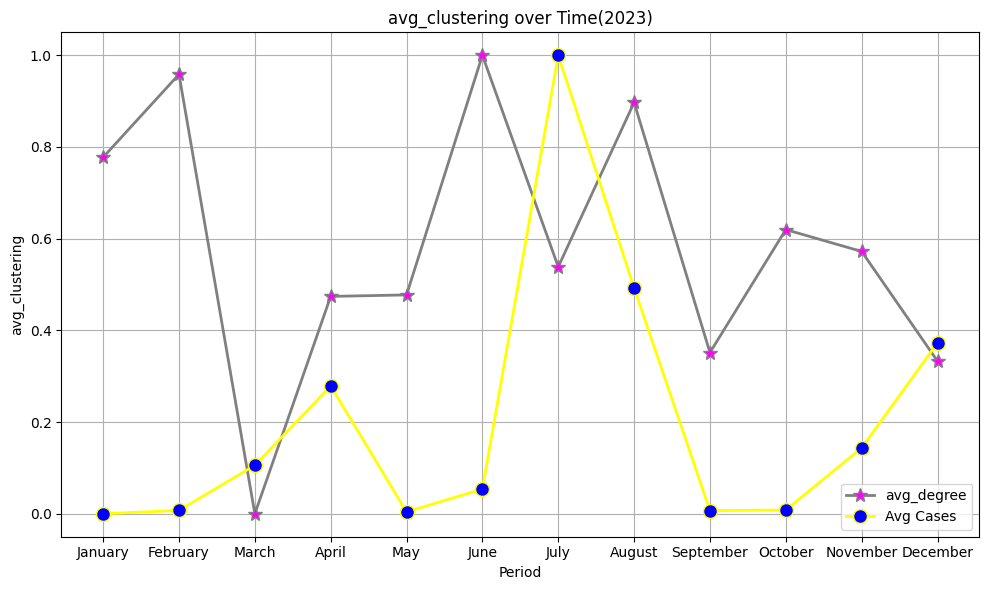

In [ ]:
def clustering_coefficient(data):
    vis_graph = visibility_graph(data)
    if vis_graph.number_of_nodes() > 0:
        clust_coeff = nx.average_clustering(vis_graph)
        return clust_coeff

        #return sum(clust_coeff.values())/len(clust_coeff)
    else:
        return 0

def avg(data):
   k=sum(data)/len(data)
   return k

avc = []
average_value1= []

for i in window:
  data=window[i]
  print(data)
  G= nx.visibility_graph(data)
  #avc.append(clustering_coefficient(data))
  #average_value1.append(avg(data))
  avc.append(nx.average_clustering(G))
  average_value1.append(data.mean())

x= max(average_value1)
y=max(avc)

scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc).reshape(-1,1))
plt.figure(figsize=(10,6))
plt.plot(range(len(window)), scaled_path1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Cases") # Changed range to len(window)

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Period')
plt.ylabel('avg_clustering')
plt.title('avg_clustering over Time(2023)')
plt.xticks(range(len(window)),month_names)
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'lower right')
plt.show()


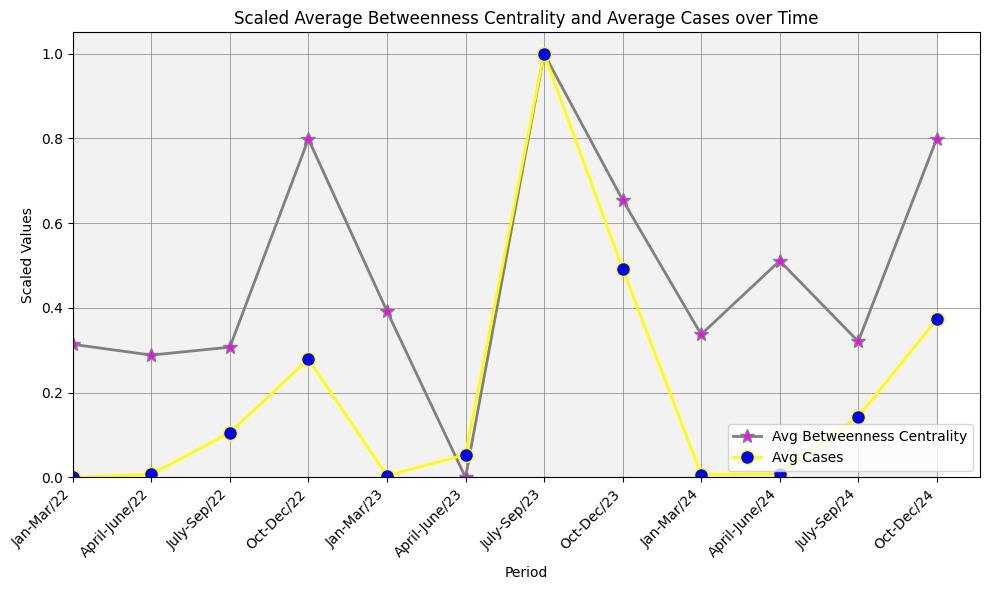

In [ ]:
def betweenness_centrality(data):
    vis_graph = visibility_graph(data)
    if vis_graph.number_of_nodes() > 0:
        cen = nx.betweenness_centrality(vis_graph)
        # Return the average of the betweenness centrality values
        if cen:
            return np.mean(list(cen.values()))
        else:
            return 0.0
    else:
        return 0.0

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avg_cen = []
average_value_cen = []

for i in window:
  data=window[i]
  #print(data)
  avg_cen_score = betweenness_centrality(data)
  avg_cen.append(avg_cen_score)
  average_value_cen.append(avg(data))

scaler = MinMaxScaler()
# Scale the values
scaled_avg_cases_cen = scaler.fit_transform(np.array(average_value_cen).reshape(-1,1))
scaled_avg_cen =  scaler.fit_transform(np.array(avg_cen).reshape(-1,1))


fig, ax = plt.subplots(figsize=(10,6))

# Shade between x=3 and x=6
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.1)


#plt.figure(figsize=(10,6))
# Plotting from index 0
ax.plot(range(len(window)), scaled_avg_cen, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="Avg Betweenness Centrality")
ax.plot(range(len(window)), scaled_avg_cases_cen, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Cases")

#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Period')
plt.ylabel('Scaled Values')
plt.title('Scaled Average Betweenness Centrality and Average Cases over Time')
# Setting xticks from index 0

plt.xticks(range(len(window)), month_names)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.grid(True)
ax.grid(True, color='gray', linestyle='-', linewidth=0.7, alpha=0.7)


ax.legend(loc = 'lower right')
plt.show()

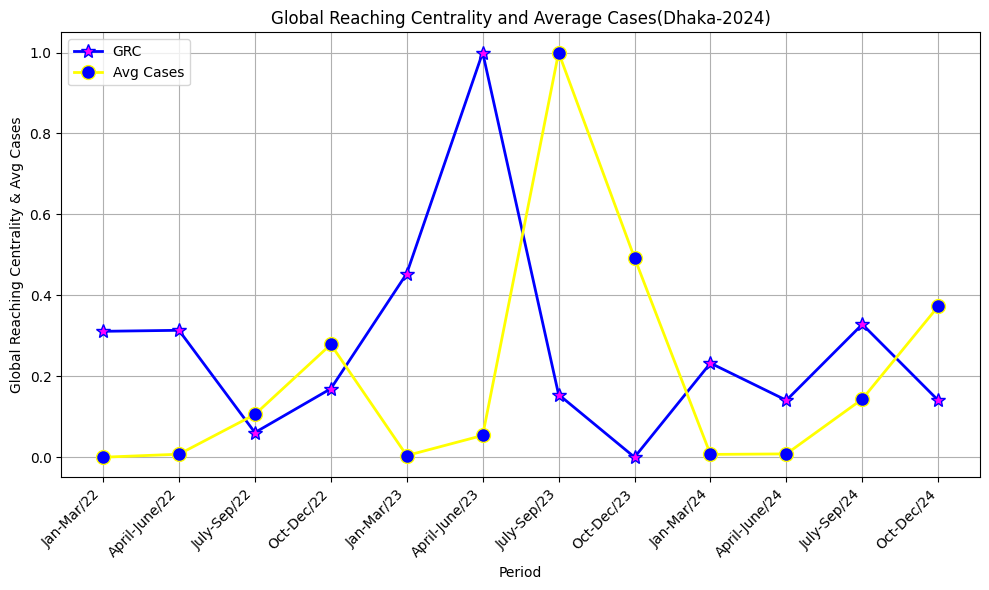

In [ ]:
def reaching_centrality(data):
  vis_graph = visibility_graph(data)
  if vis_graph.number_of_nodes() > 0:
    avg_gr_centrality = nx.global_reaching_centrality(vis_graph)
    return avg_gr_centrality
  else:
    return 0

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc1 = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  avc1.append(reaching_centrality(data))
  average_value1.append(avg(data))


x= max(average_value1)
y=max(avc1)

scaler = MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc1).reshape(-1,1))
plt.figure(figsize=(10,6))
# Plotting from index 0
plt.plot(range(len(window)), scaled_path1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='blue', label="GRC")
plt.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Cases")
#month_names = ['Jan-Feb/22', 'Mar-Apr/22', 'May-June/22', 'July-Aug/22', 'Sep-Oct/22', 'Nov-Dec/22', 'Jan-Feb/23', 'Mar-Apr/23', 'May-June/23', 'July-Aug/23', 'Sep-Oct/23', 'Nov-Dec/24', 'Mar-Apr/24', 'May-June/24', 'July-Aug/24', 'Sep-Oct/24', 'Nov-Dec/24']
month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
#month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xlabel('Period')
plt.ylabel('Global Reaching Centrality & Avg Cases')
plt.title('Global Reaching Centrality and Average Cases(Dhaka-2024)')
# Setting xticks from index 0
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper left')
plt.show()

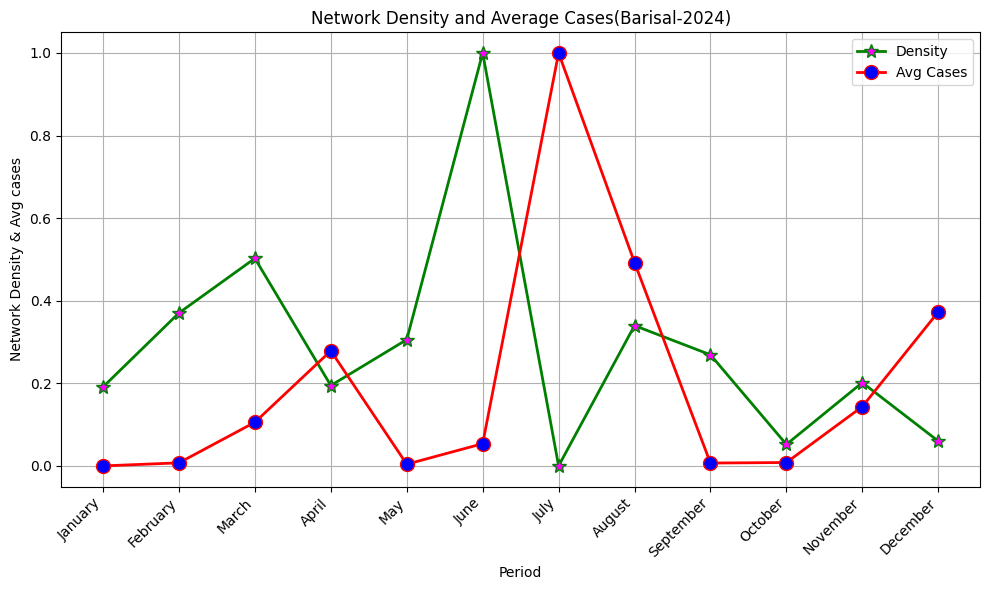

In [ ]:
def network_density(data):
  vis_graph = visibility_graph(data)
  dens = nx.density(vis_graph)
  return dens

def avg(data):
   #print(data)
   k=sum(data)/len(data)
   return k

avc2 = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  avc2.append(network_density(data))
  average_value1.append(avg(data))


x= max(average_value1)
y=max(avc2)

scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path=  scaler.fit_transform(np.array(avc2).reshape(-1,1))

plt.figure(figsize=(10,6))
plt.plot(range(len(window)), scaled_path, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='green', label="Density") # Changed range to len(window)
plt.plot(range(len(window)), scaled_value1, markerfacecolor='blue', markersize=10, marker='o', linewidth=2, linestyle='-', color='red', label="Avg Cases") # Changed range to len(window)
#month_names = ['Jan-Feb/22', 'Mar-Apr/22', 'May-June/22', 'July-Aug/22', 'Sep-Oct/22', 'Nov-Dec/22', 'Jan-Feb/23', 'Mar-Apr/23', 'May-June/23', 'July-Aug/23', 'Sep-Oct/23', 'Nov-Dec/23','Jan-Feb/24', 'Mar-Apr/24', 'May-June/24', 'July-Aug/24', 'Sep-Oct/24', 'Nov-Dec/24']
#month_names =['Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22','Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23','Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24']
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.xlabel('Period')
plt.ylabel('Network Density & Avg cases')
plt.title('Network Density and Average Cases(Barisal-2024)')
plt.xticks(range(len(window)), month_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()